In [1]:
from FIT_python.step_01_data_import.utils import load_raw_files
from FIT_python.config import RAW_DIR
raw_dfs = load_raw_files(RAW_DIR)
raw_dfs

{'Amur_Tiger':                  id                  species individual_id   trail sex  \
 0      Amur_Tiger_1  Panthera tigris altaica          M541  M541 A   M   
 1      Amur_Tiger_2  Panthera tigris altaica          M541  M541 A   M   
 2      Amur_Tiger_3  Panthera tigris altaica          M541  M541 A   M   
 3      Amur_Tiger_4  Panthera tigris altaica          M541  M541 A   M   
 4      Amur_Tiger_5  Panthera tigris altaica          M541  M541 A   M   
 ..              ...                      ...           ...     ...  ..   
 600  Amur_Tiger_601  Panthera tigris altaica         M1084   M1084   M   
 601  Amur_Tiger_602  Panthera tigris altaica         M1084   M1084   M   
 602  Amur_Tiger_603  Panthera tigris altaica         M1084   M1084   M   
 603  Amur_Tiger_604  Panthera tigris altaica         M1084   M1084   M   
 604  Amur_Tiger_605  Panthera tigris altaica         M1084   M1084   M   
 
            v1        v2        v3        v4        v5  ...       area1  \
 0    3.2

In [2]:
from FIT_python.step_02_a_splitting_train_test.wrapper import SplitWrapper

splitper = SplitWrapper()
splitper.split_all()



📊 amur_tiger – train – 476 Zeilen | 35 Individuen | 68 Trails
sex
f    265
m    211

📊 amur_tiger – test – 129 Zeilen | 9 Individuen | 18 Trails
sex
f    79
m    50

📊 amur_tiger – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ amur_tiger gespeichert (csv & parquet)

📊 eurasian_otter – train – 515 Zeilen | 39 Individuen | 66 Trails
sex
f          259
m          189
unknown     67

📊 eurasian_otter – test – 113 Zeilen | 10 Individuen | 15 Trails
sex
m          61
f          38
unknown    14

📊 eurasian_otter – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ eurasian_otter gespeichert (csv & parquet)


0

[SUCCESS] summary written to C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\summary.csv


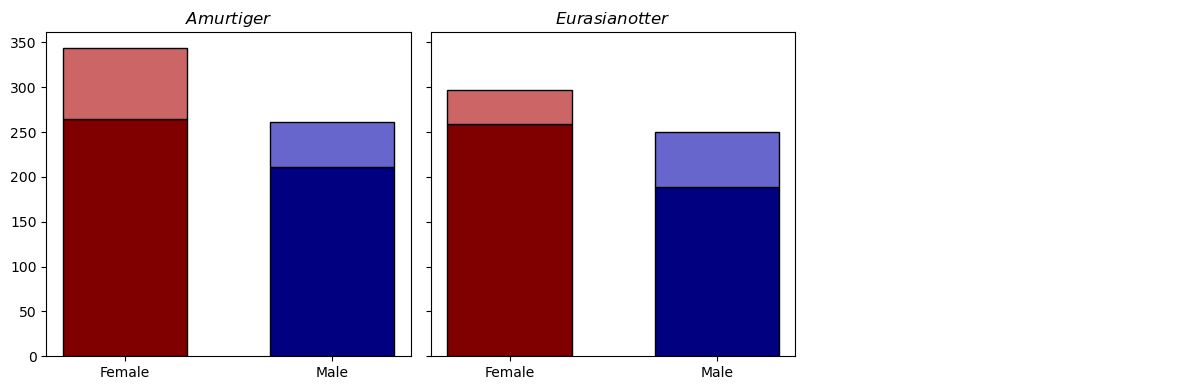

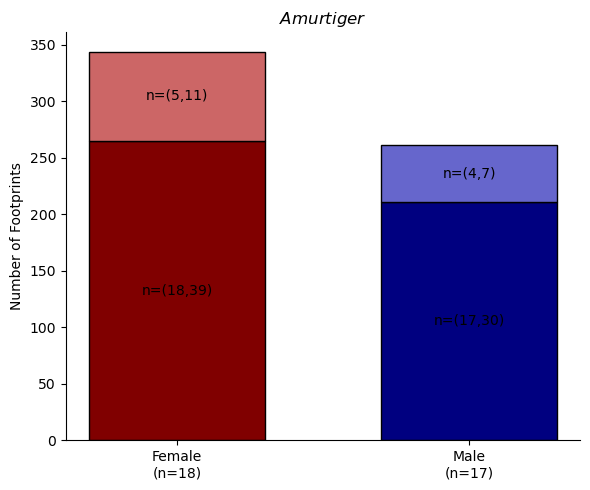

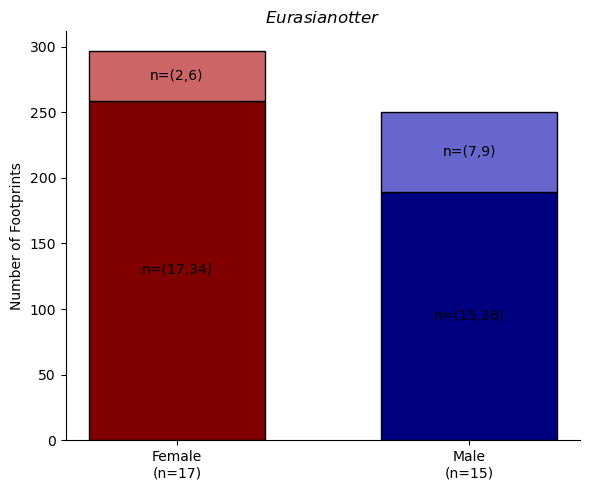

0

In [3]:
from FIT_python.step_02_b_summary_datasets.wrapper import SummaryWrapper
summary = SummaryWrapper()
summary.summarize_all()

In [ ]:
from sklearn.model_selection import ParameterGrid
from FIT_python.pipeline.pipeline_wrapper import PipelineWrapper
import pandas as pd

# --- Minimal-Grid für einen Schnelltest ---
param_grid = {
    # Imputation: nur None
    'impute_method':    [None],               
    # Outlier-Cleaning: keine, Clip oder Z-Score
    'outlier_method':   [None, 'clip', 'zscore'],
    # Scaling: keine, Standard oder Robust
    'scaler_method':    [None, 'standard', 'robust'],
    # DimRed vor Selektion: keine oder PCA
    'reduce_pre_method':[None, 'pca'],
    # DimRed nach Selektion: keine oder PCA
    'reduce_post_method':[None, 'pca'],
    # Anzahl Features beim Forward-Select
    'fs_k':             [5, 10, 20, 50, 100]
}

# So viele Kombinationen sind das:
num_combinations = len(list(ParameterGrid(param_grid)))
print(f"Anzahl Parameter-Kombinationen: {num_combinations}")


results = []
for params in ParameterGrid(param_grid):
    print("Teste Konfiguration:", params)
    # fs_method bleibt 'forward' oder 'random_forest' je nach deinem Wunsch
    pw = PipelineWrapper(
        model_keys=['svm', 'lda'],       # oder None für alle Modelle
        fs_method='forward',             # dein Feature-Selector
        fs_k=params.pop('fs_k'),
        **params
    )
    df_res = pw.run()
    # Metadaten ergänzen
    for k, v in params.items():
        df_res[k] = v
    df_res['fs_k'] = pw.fs_k
    results.append(df_res)

# Ergebnisse zusammenführen
df_all = pd.concat(results, ignore_index=True)
df_all.head()


Anzahl Parameter-Kombinationen: 180
Teste Konfiguration: {'fs_k': 5, 'impute_method': None, 'outlier_method': None, 'reduce_post_method': None, 'reduce_pre_method': None, 'scaler_method': None}

📊 amur_tiger – train – 476 Zeilen | 35 Individuen | 68 Trails
sex
f    265
m    211

📊 amur_tiger – test – 129 Zeilen | 9 Individuen | 18 Trails
sex
f    79
m    50

📊 amur_tiger – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ amur_tiger gespeichert (csv & parquet)

📊 eurasian_otter – train – 515 Zeilen | 39 Individuen | 66 Trails
sex
f          259
m          189
unknown     67

📊 eurasian_otter – test – 113 Zeilen | 10 Individuen | 15 Trails
sex
m          61
f          38
unknown    14

📊 eurasian_otter – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ eurasian_otter gespeichert (csv & parquet)
Teste Konfiguration: {'fs_k': 5, 'impute_method': None, 'outlier_method': None, 'reduce_post_method': None, 'reduce_pre_method': None, 'scaler_method': 'standard'}

📊 a